In [9]:
# Re-import needed packages after kernel reset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


In [10]:
# Reload dataset
df = pd.read_csv("dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df = df[['Date', 'Adj Close']].dropna()
df.set_index('Date', inplace=True)

# Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Sequence
SEQ_LENGTH = 50
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Split
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [11]:
# Model
def build_lstm_model(input_shape):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.3), input_shape=input_shape),
        Bidirectional(LSTM(32, dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

model = build_lstm_model((X_train.shape[1], X_train.shape[2]))

# Callbacks
callbacks = [
    EarlyStopping(patience=30, restore_best_weights=True),
    ModelCheckpoint('/mnt/data/best_lstm_model.keras', save_best_only=True),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)
]

# Train
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

# Prediction
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Inverse
def inverse_transform_predictions(scaler, predictions, feature_index=0):
    dummy = np.zeros((len(predictions), scaler.data_max_.shape[0]))
    dummy[:, feature_index] = predictions.flatten()
    return scaler.inverse_transform(dummy)[:, feature_index]

y_train_inv = inverse_transform_predictions(scaler, y_train.reshape(-1, 1))
y_test_inv = inverse_transform_predictions(scaler, y_test.reshape(-1, 1))
train_pred_inv = inverse_transform_predictions(scaler, train_pred)
test_pred_inv = inverse_transform_predictions(scaler, test_pred)



Epoch 1/200


c:\Users\yunan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - loss: 0.0280 - mae: 0.1191 - val_loss: 0.0060 - val_mae: 0.0461 - learning_rate: 0.0010
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0096 - mae: 0.0647 - val_loss: 0.0072 - val_mae: 0.0591 - learning_rate: 0.0010
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0097 - mae: 0.0619 - val_loss: 0.0061 - val_mae: 0.0580 - learning_rate: 0.0010
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0078 - mae: 0.0548 - val_loss: 0.0065 - val_mae: 0.0601 - learning_rate: 0.0010
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0065 - mae: 0.0521 - val_loss: 0.0047 - val_mae: 0.0506 - learning_rate: 0.0010
Epoch 6/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0062 - mae: 0.0489 - val_loss: 0.0044 - val_mae: 0.0462 - learning_rate: 0.0010
Epoch 7/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0068 - mae: 0.0495 - val_loss: 0.0040 - val_mae: 0.0432 - learning_rate: 0.0010
Epoch 8/200
94/94

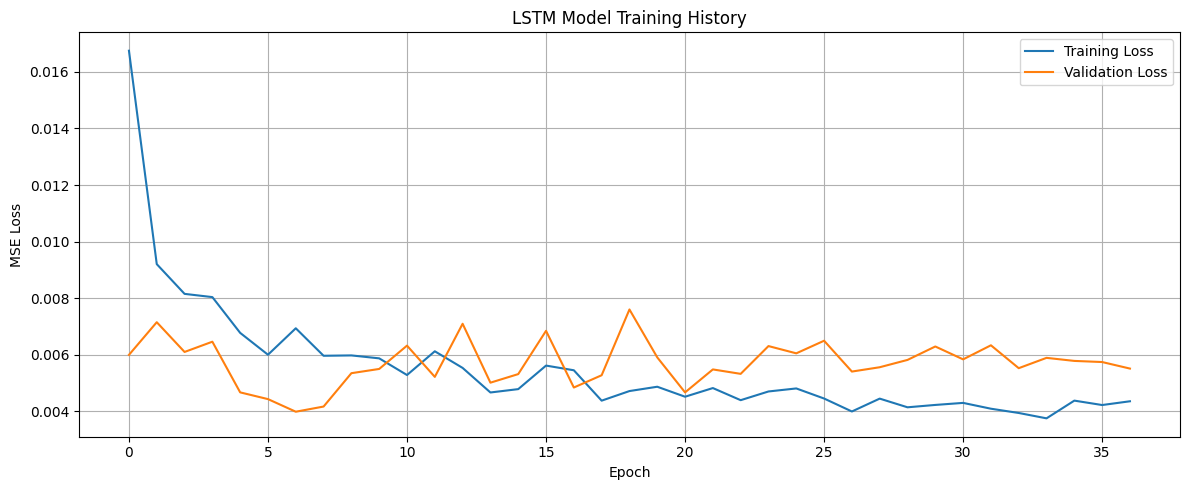


=== LSTM Evaluation Results ===
Dataset        MAE       RMSE
  Train 204.504628 258.536822
   Test 125.626041 183.811040


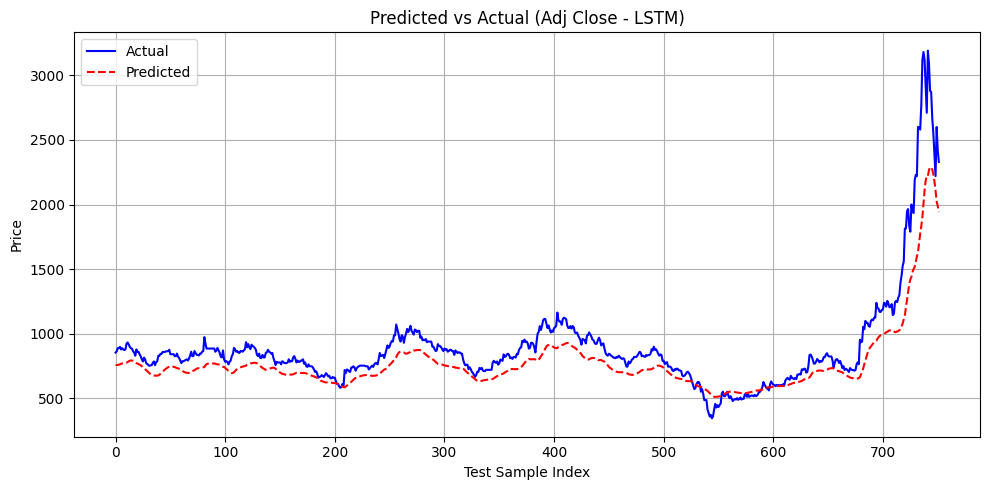

In [12]:
# Loss Plot
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/mnt/data/lstm_loss_plot.png", dpi=300)
plt.show()

# Evaluation
train_mae = mean_absolute_error(y_train_inv, train_pred_inv)
test_mae = mean_absolute_error(y_test_inv, test_pred_inv)
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_pred_inv))
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_pred_inv))

results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse]
})

print("\n=== LSTM Evaluation Results ===")
print(results.to_string(index=False))

# Plot Predicted vs Actual
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label='Actual', color='blue')
plt.plot(test_pred_inv, label='Predicted', linestyle='--', color='red')
plt.title("Predicted vs Actual (Adj Close - LSTM)")
plt.xlabel("Test Sample Index")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/mnt/data/lstm_prediction_vs_actual.png", dpi=300)
plt.show()
